In [1]:
%gui qt

In [2]:
%gui notebook

In [3]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from marxs import source, optics
from marxs.simulator import Sequence
from marxs import source, simulator
from marxs.optics import MultiAperture, CircleAperture,FlatStack
import numpy as np
import matplotlib.pyplot as plt
from marxs.optics.marx import MarxMirror
import os
import marxs

/home/ritika/marxs/venv2.0/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
marxm = marxs.optics.marx.MarxMirror(parfile='test_source.par') #parameter file with the path to .rdb file 

	/home/ritika/marxs/XMM_M4_nested.rdb
File successfully opened
mirror: p1
mirror: p2
mirror: p3
mirror: p4
mirror: p5
mirror: p6
mirror: p7
mirror: p8
mirror: p9
mirror: p10
mirror: p11
mirror: p12
mirror: p13
mirror: p14
mirror: p15
mirror: p16
mirror: p17
mirror: p18
mirror: p19
mirror: p20
mirror: p21
mirror: p22
mirror: p23
mirror: p24
mirror: p25
mirror: p26
mirror: p27
mirror: p28
mirror: p29
mirror: p30
mirror: p31
mirror: p32
mirror: p33
mirror: p34
mirror: p35
mirror: p36
mirror: p37
mirror: p38
mirror: p39
mirror: p40
mirror: p41
mirror: p42
mirror: p43
mirror: p44
mirror: p45
mirror: p46
mirror: p47
mirror: p48
mirror: p49
mirror: p50
mirror: p51
mirror: p52
mirror: p53
mirror: p54
mirror: p55
mirror: p56
mirror: p57
mirror: p58


Hello From HRMA 6. 
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_axis angle (in radians) : 0.022689
off_a

In [20]:
from marxs.optics import FlatDetector
from marxs.design import uncertainties
#det = optics.FlatDetector(position=[6710, 0,0 ], zoom=[1, 150, 150], pixsize=0.0015)
det = optics.FlatDetector(position=[-310, 0, 0 ], zoom=[1, 500, 500], pixsize=0.0005)

Plotting for off-axis 0.0 (in deg)
Plotting for off-axis 0.1 (in deg)
Plotting for off-axis 0.2 (in deg)
Plotting for off-axis 0.3 (in deg)
Plotting for off-axis 0.4 (in deg)
Plotting for off-axis 0.5 (in deg)
Plotting for off-axis 1.0 (in deg)
Plotting for off-axis 1.1 (in deg)


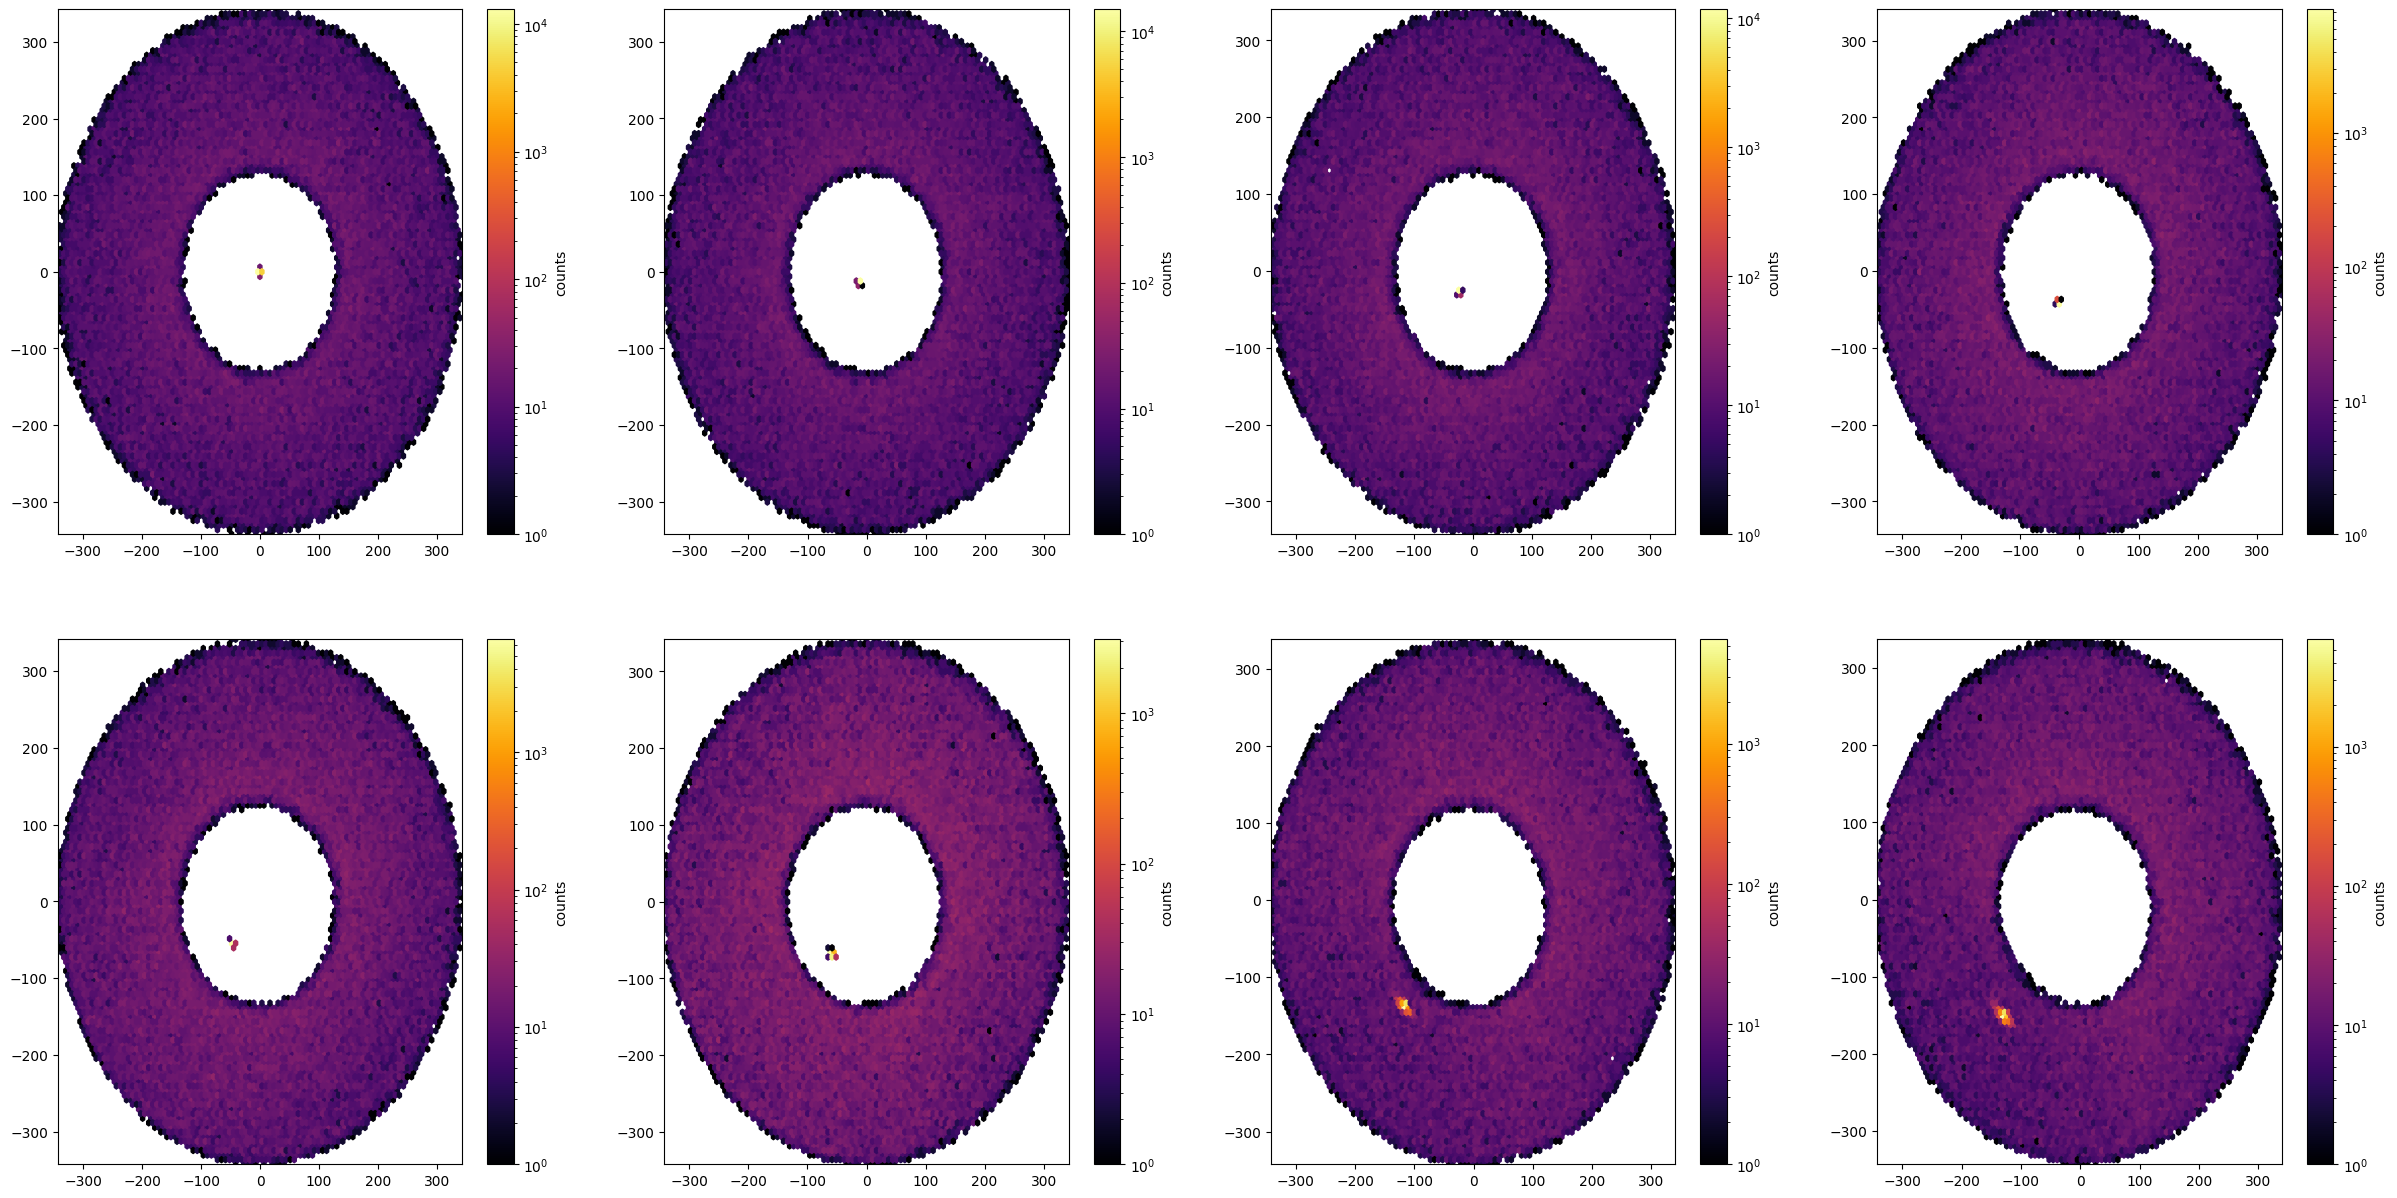

In [23]:
off =np.array([0.0,0.1,0.2,0.3,0.4,0.5,1.0,1.1])
ra = 30
dec = 30
pos = simulator.KeepCol('pos')
instrum = simulator.Sequence(elements=[marxm,det], postprocess_steps=[pos])
ncols=4
nrows=2
fig, ax = plt.subplots(nrows, ncols, figsize=(30,15))

for i in range(len(off)):
    star = marxs.source.PointSource(coords= SkyCoord(ra+off[i], dec+off[i], unit="deg"), flux= 1e2 / u.s / u.cm**2, energy= 10* u.keV )
    pointing = marxs.source.FixedPointing(coords=SkyCoord(ra, dec, unit='deg'))
    photons = star.generate_photons(1e3 * u.s)
    photons = pointing(photons)
    photons = instrum(photons)
    #ind = (photons['unreflected'] == True)
    #photons = photons[ind]
    posdat = pos.format_positions()
    #posdat = pos.format_positions()[ind,:,:]
    #print(photons)

    x = photons['det_x']
    y = photons['det_y']

    if (i<4):
        nrow = 0
        ncol = i
    else:
        nrow = 1 
        ncol = i-4
    print("Plotting for off-axis {} (in deg)".format(off[i]))

    xlim = x.min(), x.max()
    ylim = y.min(), y.max()

    hb = ax[nrow, ncol].hexbin(x, y, gridsize=100, bins= 'log', cmap='inferno')
    ax[nrow, ncol].set(xlim=xlim, ylim=ylim)
    #ax.set_title("Testing XMM binned plots")
    cb = fig.colorbar(hb, ax=ax[nrow, ncol], label='counts')
    
plt.savefig("test_10kev_2.png")
plt.show()

In [16]:
from marxs.optics import FlatDetector
from marxs.design import uncertainties
det = optics.FlatDetector(position=[-310, 0,0 ], zoom=[1, 150, 150], pixsize=0.00015)

pos = simulator.KeepCol('pos')
star = marxs.source.PointSource(coords= SkyCoord(30, 30, unit="deg"), 
                               flux = 1e1 / u.s / u.cm**2, energy=1.5* u.keV )
pointing = marxs.source.FixedPointing(coords=SkyCoord(30, 30, unit='deg'))
photons = star.generate_photons(1e3* u.s)
instrum = simulator.Sequence(elements=[marxm,det], postprocess_steps=[pos])
photons = pointing(photons)
photons = instrum(photons)
ind = (photons['unreflected'] == False)
photons = photons[ind]
posdat = pos.format_positions()[ind,:,:]
photons

pos,dir,energy,time,tag,unreflected,mirror_vblocked,mirror_shell,time_beforemirror,energy_beforemirror,polangle,probability,ra,dec,dir_beforemirror,polarization,pos_beforemirror,detpix_x,detpix_y,det_x,det_y
,,,,,,,,s,keV,rad,,deg,deg,,,,,,,
float64[4],float64[4],float64,float64,int64,bool,bool,int64,float64,float64,float64,float64,float64,float64,float64[4],float64[4],float64[4],float64,float64,float64,float64
-310.0 .. 1.0,-0.9995949867224648 .. 0.0,1.5,0.1,1,False,False,26,0.1,1.5,1.961238801853152,1.0,30.0,30.0,-1.0 .. 0.0,0.021608314268432606 .. 0.0,0.0 .. 1.0,1000466.2698513024,1000153.2052425899,0.07001547769536387,0.023055786388482602
-310.0 .. 1.0,-0.9997211744330194 .. 0.0,1.5,0.7000000000000001,7,False,False,13,0.7000000000000001,1.5,1.0828198527706796,1.0,30.0,30.0,-1.0 .. 0.0,0.019439593474546418 .. 0.0,0.0 .. 1.0,999708.8311937611,999440.0179869458,-0.043600320935837544,-0.08392230195812544
-310.0 .. 1.0,-0.9992522934926024 .. 0.0,1.5,0.8,8,False,False,47,0.8,1.5,0.6107006420032645,1.0,30.0,30.0,-1.0 .. 0.0,0.011151616183284679 .. 0.0,0.0 .. 1.0,1000522.5056861537,999335.9638464997,0.07845085292305498,-0.099530423025044
-310.0 .. 1.0,-0.9996669634796298 .. 0.0,1.5,1.4000000000000001,14,False,False,19,1.4000000000000001,1.5,5.3122953157204424,1.0,30.0,30.0,-1.0 .. 0.0,0.016730516063951144 .. 0.0,0.0 .. 1.0,1000083.523840229,999205.7190420112,0.012603576034347697,-0.11906714369831661
-310.0 .. 1.0,-0.9992346515395272 .. 0.0,1.5,1.7000000000000002,17,False,False,48,1.7000000000000002,1.5,5.6566983747437085,1.0,30.0,30.0,-1.0 .. 0.0,-0.03589112812949189 .. 0.0,0.0 .. 1.0,1000107.6517967298,999510.2161842156,0.01622276950946855,-0.07339257236765206
-310.0 .. 1.0,-0.9990823597064136 .. 0.0,1.5,1.9000000000000001,19,False,False,55,1.9000000000000001,1.5,1.0384836722628894,1.0,30.0,30.0,-1.0 .. 0.0,-0.032205586364678206 .. 0.0,0.0 .. 1.0,994686.5964199491,1001007.471488952,-0.7969355370076414,0.15119572334280917
-310.0 .. 1.0,-0.9990458004676745 .. 0.0,1.5,2.0,20,False,False,56,2.0,1.5,0.8659171240189509,1.0,30.0,30.0,-1.0 .. 0.0,0.031147790658027936 .. 0.0,0.0 .. 1.0,1002803.3144249191,999797.5588531581,0.4205721637378588,-0.030291172026274182
-310.0 .. 1.0,-0.9991514148914953 .. 0.0,1.5,3.1,31,False,False,52,3.1,1.5,6.156251561538699,1.0,30.0,30.0,-1.0 .. 0.0,0.016791651914104096 .. 0.0,0.0 .. 1.0,996587.8716284736,1001028.6617822618,-0.5117442557289564,0.1543742673392785


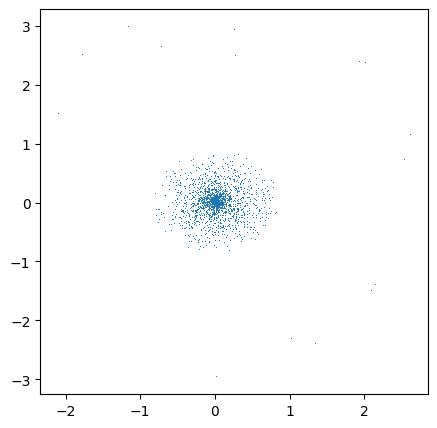

In [17]:
fig, ax = plt.subplots(figsize=(5,5))

x = photons['det_x']
y = photons['det_y']

plt.plot(x,y, ',')

plt.savefig("test_xmm.png")
plt.show()

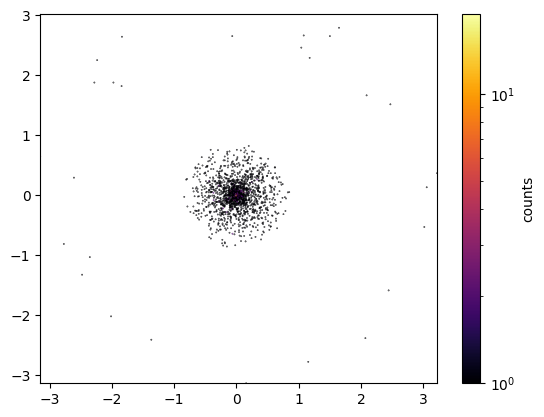

In [12]:
xlim = x.min(), x.max()
ylim = y.min(), y.max()
fig, ax = plt.subplots()
hb = ax.hexbin(x, y, gridsize=1000, bins='log', cmap='inferno')
ax.set(xlim=xlim, ylim=ylim)
#ax.set_title("Testing XMM binned plots")
cb = fig.colorbar(hb, ax=ax, label='counts')
plt.savefig("test_xmm_cb.png")
plt.show()

In [14]:
from mayavi import mlab
from marxs.visualization.mayavi import plot_object, plot_rays
fig = mlab.figure(bgcolor=(1,1,1))
obj = plot_object(instrum, viewer=fig)
rays = plot_rays(posdat, scalar=None,
                 kwargssurface={'opacity':1,
                                'line_width':1,
                                 'colormap': 'blue-red'})
mlab.show()

In [153]:
interact = np.where(photons['tag'] == 10)
print(photons[interact]['pos'][0])
print(photons[interact]['dir'][0])
print(photons[interact]['dir_beforemirror'][0])
print(photons[interact]['pos_beforemirror'][0])

[ 190.91323481  -99.21791905 -210.09173476    1.        ]
[-0.99105414  0.03670604  0.12831349  0.        ]
[-0.99600669 -0.05652655 -0.06910445  0.        ]
[0. 0. 0. 1.]
